In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
sales = pd.read_csv("C:/Users/navee/Desktop/InfoByte_Pjts/L1-P1/retail_sales_dataset.csv")

sales.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [18]:
print(sales.columns)
sales.info()

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [19]:
sales.columns = sales.columns.str.strip().str.lower().str.replace(" ", "_")

print(sales.columns)

Index(['transaction_id', 'date', 'customer_id', 'gender', 'age',
       'product_category', 'quantity', 'price_per_unit', 'total_amount'],
      dtype='object')


In [20]:
if 'date' in sales.columns:
    sales['date'] = pd.to_datetime(sales['date'])

In [21]:
if 'total_amount' in sales.columns:
    sales['sales'] = sales['total_amount']

elif 'price_per_unit' in sales.columns and 'quantity' in sales.columns:
    sales['sales'] = sales['price_per_unit'] * sales['quantity']

elif 'price' in sales.columns and 'quantity' in sales.columns:
    sales['sales'] = sales['price'] * sales['quantity']

else:
    raise ValueError("No usable sales columns found. Check dataset.")

In [22]:
sales.describe()

,transaction_id,date,age,quantity,price_per_unit,total_amount,sales
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632,559.997632


In [23]:
print("Mean Sales:", sales['sales'].mean())
print("Median Sales:", sales['sales'].median())
print("Mode Sales:", sales['sales'].mode())

Mean Sales: 456.0
Median Sales: 135.0
Mode Sales: 0    50
Name: sales, dtype: int64


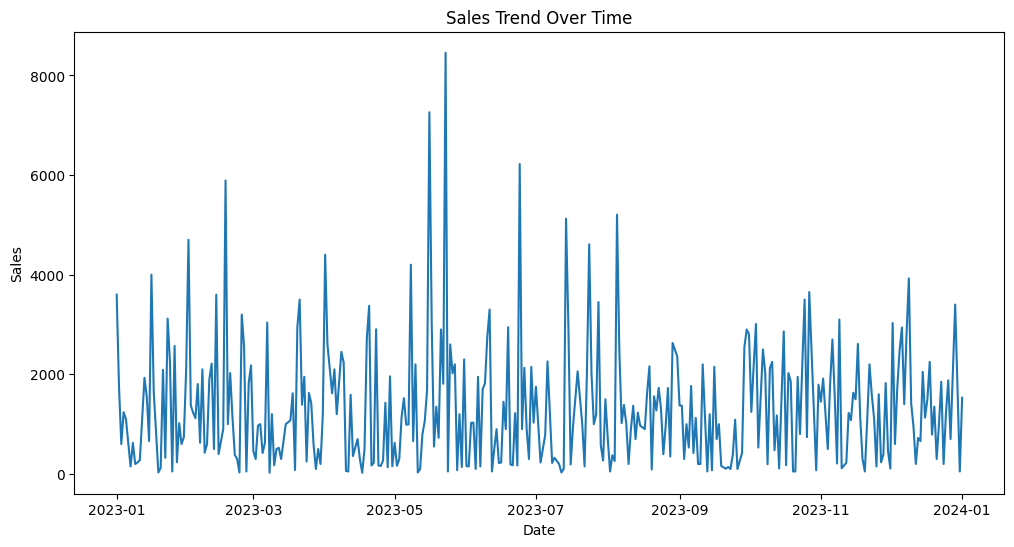

In [24]:
if 'date' in sales.columns:

    trend = sales.groupby('date')['sales'].sum()

    plt.figure(figsize=(12,6))
    plt.plot(trend)
    plt.title("Sales Trend Over Time")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.show()

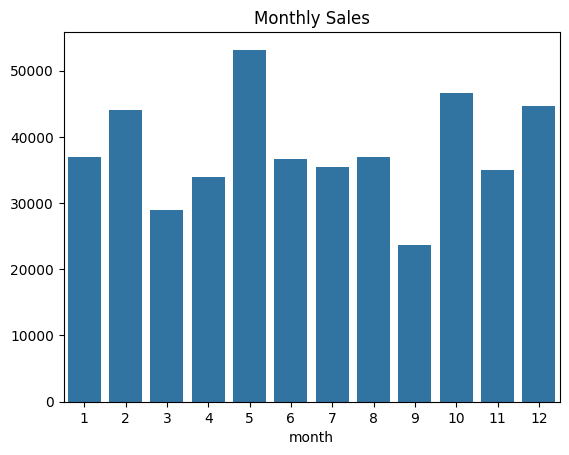

In [25]:
if 'date' in sales.columns:

    sales['month'] = sales['date'].dt.month

    monthly_sales = sales.groupby('month')['sales'].sum()

    sns.barplot(x=monthly_sales.index, y=monthly_sales.values)

    plt.title("Monthly Sales")
    plt.show()

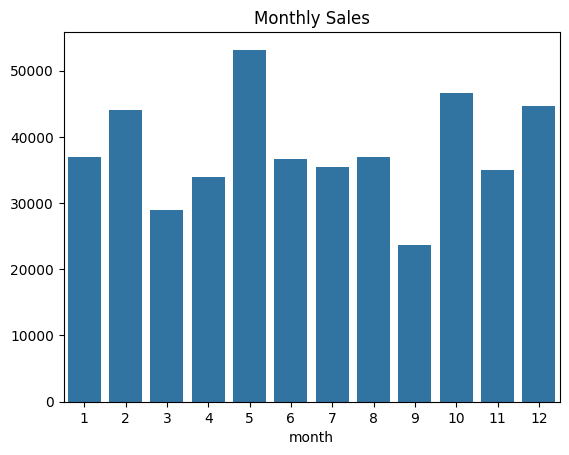

In [26]:
if 'date' in sales.columns:

    sales['month'] = sales['date'].dt.month

    monthly_sales = sales.groupby('month')['sales'].sum()

    sns.barplot(x=monthly_sales.index, y=monthly_sales.values)

    plt.title("Monthly Sales")
    plt.show()

In [27]:
if 'product_category' in sales.columns:

    category_sales = sales.groupby('product_category')['sales'].sum()

    category_sales.sort_values(ascending=False)

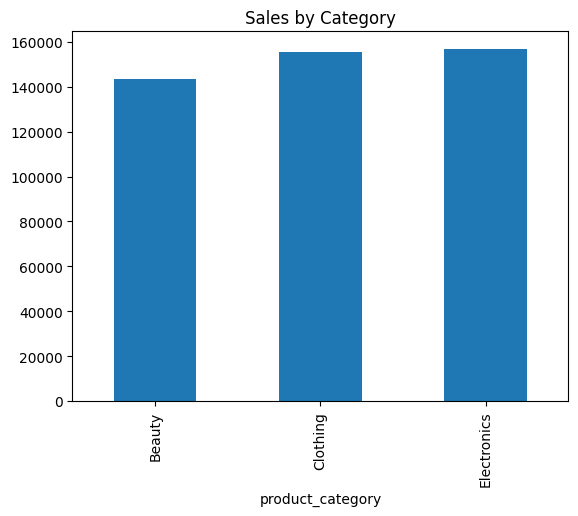

In [28]:
if 'product_category' in sales.columns:

    category_sales.plot(kind='bar')

    plt.title("Sales by Category")
    plt.show()

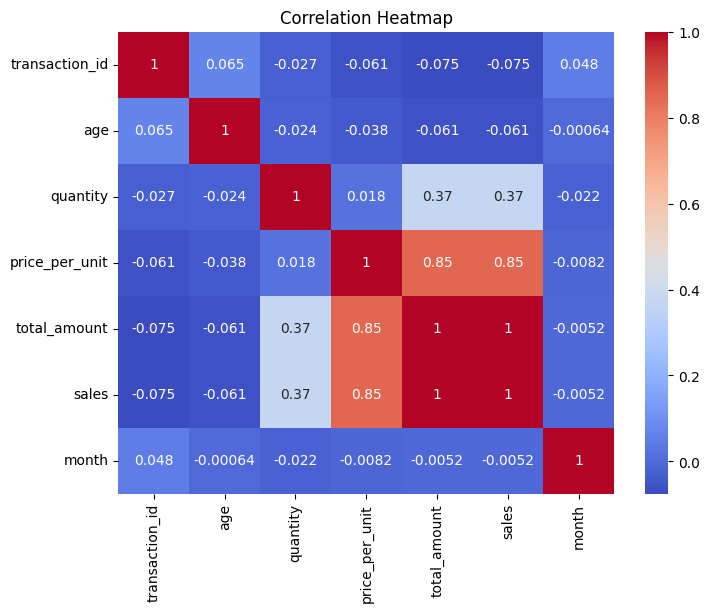

In [29]:
plt.figure(figsize=(8,6))

sns.heatmap(sales.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

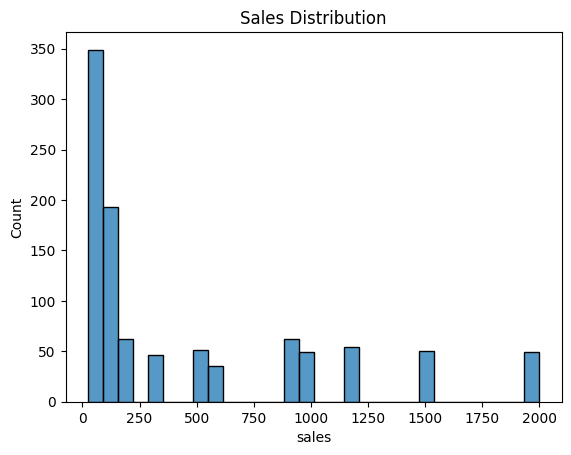

In [30]:
sns.histplot(sales['sales'], bins=30)

plt.title("Sales Distribution")

plt.show()